## music service chatbot

### 목적 : 
- 차량 운전중 음악 추천 
- 날씨에 어울리는 음악 추천
- A곡과 비슷한 B곡 추천
- PDF 기반 검색
- 수집된 데이터 기반 python 코드 활용 차트 비교
- CS 상담



Q : 오늘 날씨에 어울리는 재즈 추천해줘, 내가 사는 곳은 서울이야

feedback_node : no

plan_node : 

[오늘 서울 날씨에 어울리는 재즈 음악 목록을 생성합니다.

생성된 음악 목록에서 서비스에서 이용 가능한 음악을 검증합니다.

최종 음악 목록을 선정하여 추천합니다.]

start_node -> routing

final_node -> tool 사용 여부 확인

A :  web_search_agent 사용하여 진행할까여 ?

Q : 응 검색해

feedback_node : yes

start_node -> routing

agent 사용 -> 검색 결과 제시

final_node -> 검색 내용 기반 최종 답변

A :  web_search_agent,  query: 오늘 서울 날씨


### 기본 구성

In [1]:
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("utils"), "..")))
from module.utils import *
from module.prompt import *
from module.custom_model import *
from module.base_model import *
from module.tools import *

In [2]:
start_langsmith("final_music")

LangSmith 추적을 시작합니다.
[프로젝트명]
final_music


In [3]:
from typing import TypedDict, Annotated, List, Literal, Tuple
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks

### SQL graph

In [4]:
class SubState(TypedDict):
    question: Annotated[str, "user input question"]  # 사용자 질의 or requeustion 질의
    plan: Annotated[list[str], "get plan_node"]  # llm 생성한 작업 계획서
    messages: Annotated[list, add_messages]  # 작업 수행 후 얻은 데이터
    past_steps: Annotated[list, add_messages]  # 현재 단계에서 수행한 결과
    answer: Annotated[str, " output final answer"]  # 최종 답변 출력
    human_feedback: bool = False

In [5]:
@tool
def db_query_tool(query: str) -> str:
    """
    Run SQL queries against a database and return results
    Returns an error message if the query is incorrect
    If an error is returned, rewrite the query, check, and retry
    """
    # 쿼리 실행
    db = get_db()
    result = db.run_no_throw(query)

    # 오류: 결과가 없으면 오류 메시지 반환
    if "Error" in result:
        return f"Error: {result} \n\n . Please rewrite your query and try again."
    # 정상: 쿼리 실행 결과 반환
    elif not result:
        return "Success: value is None"
    else:
        return f"Success: {result}"

In [6]:
def instruction_node(state: SubState):
    plan = state["plan"]
    text_plan = "\n".join(f"{idx+1}. {text}" for idx, text in enumerate(plan))
    task = plan[0]
    task_str = f"""For the following plan: \n\n {text_plan} \n\n You are tasked with executing [step 1. {task}]."""
    return SubState({"messages": [task_str]})


def get_table_list_node(state: SubState):
    llm = get_gpt()
    tools = get_db_tool(llm)
    sql_db_list_tables = next(
        tool for tool in tools if tool.name == "sql_db_list_tables"
    )
    llm_get_schema = llm.bind_tools(
        [sql_db_list_tables], tool_choice="sql_db_list_tables"
    )
    return SubState({"messages": [llm_get_schema.invoke(state["messages"])]})


def get_all_table_node(state: SubState):
    llm = get_gpt()
    tools = get_db_tool(llm)
    sql_db_list_tables = next(
        tool for tool in tools if tool.name == "sql_db_list_tables"
    )
    return ToolNode([sql_db_list_tables])


def get_one_table_info_node(state: SubState):
    llm = get_gpt()
    tools = get_db_tool(llm)
    sql_db_schema = next(tool for tool in tools if tool.name == "sql_db_schema")
    llm_with_schema = llm.bind_tools([sql_db_schema], tool_choice="sql_db_schema")
    result = llm_with_schema.invoke(state["messages"])
    return SubState({"messages": [result]})


def get_one_table_schema_node(state: SubState):
    llm = get_gemini()
    tools = get_db_tool(llm)
    sql_db_schema = next(tool for tool in tools if tool.name == "sql_db_schema")
    return ToolNode([sql_db_schema])


def get_query_gen_node(state: SubState):
    prompt = get_prompt_query_gen()
    llm = get_gpt()
    query_gen_llm = prompt | llm.bind_tools(
        [db_query_tool], tool_choice="db_query_tool"
    )
    history = state["messages"]
    query_gen = query_gen_llm.invoke({"placeholder": history})
    return SubState({"messages": [query_gen]})


#  실패시 get_query_check_node -> execute_query 로직 추가
def get_query_check_node(state: SubState):
    prompt = get_prompt_query_check()
    llm = get_gpt().bind_tools([db_query_tool], tool_choice="db_query_tool")
    chain = prompt | llm
    history = state["messages"]
    query_gen = chain.invoke({"placeholder": history})
    return SubState({"messages": [query_gen]})


def execute_query(state: SubState):
    query = ""
    messages = state["messages"][-1]
    if len(messages.tool_calls) > 0:
        query = messages.tool_calls[0]["args"]["query"]
    else:
        query = state["messages"][-1].content
    response = db_query_tool(query)
    return SubState(
        {
            "messages": ToolMessage(
                content=response, tool_call_id=state["messages"][-1].tool_calls[0]["id"]
            )
        }
    )


def answer_node(state: SubState):
    plan = state["plan"]
    task = plan[0]
    prompt = get_prompt_query_gen()
    llm = get_gemini()
    query_gen_llm = prompt | llm
    history = state["messages"]
    result = query_gen_llm.invoke({"placeholder": history})
    print(result)
    latest_messages = f" Question :{task}\n Response :{result.content}"
    return SubState(
        {
            "past_steps": [latest_messages],
            "messages": [AIMessage(content=latest_messages)],
        }
    )

In [7]:
# routing 분기처리 수행
def routing(state: SubState) -> Literal["get_query_check_node", "answer_node"]:
    latest_messages: str = state["messages"][-1].content
    if "Error:" in latest_messages:
        return "get_query_check_node"
    else:
        return "answer_node"

In [8]:
sub_state_graph = StateGraph(SubState)
sub_state_graph.add_node("instruction_node", instruction_node)
sub_state_graph.add_node("get_table_list_node", get_table_list_node)
sub_state_graph.add_node("get_all_table_node", get_all_table_node)
sub_state_graph.add_node("get_one_table_info_node", get_one_table_info_node)
sub_state_graph.add_node("get_one_table_schema_node", get_one_table_schema_node)
sub_state_graph.add_node("get_query_gen_node", get_query_gen_node)
sub_state_graph.add_node("get_query_check_node", get_query_check_node)

sub_state_graph.add_node("execute_query", execute_query)
sub_state_graph.add_node("answer_node", answer_node)

sub_state_graph.add_edge(START, "instruction_node")
sub_state_graph.add_edge("instruction_node", "get_table_list_node")
sub_state_graph.add_edge("get_table_list_node", "get_all_table_node")
sub_state_graph.add_edge("get_all_table_node", "get_one_table_info_node")
sub_state_graph.add_edge("get_one_table_info_node", "get_one_table_schema_node")

sub_state_graph.add_edge("get_one_table_schema_node", "get_query_gen_node")

sub_state_graph.add_edge("get_query_gen_node", "execute_query")
sub_state_graph.add_edge("get_query_check_node", "execute_query")
sub_state_graph.add_conditional_edges(source="execute_query", path=routing)

sub_state_graph.add_edge("answer_node", END)

sub_ck = get_check_pointer()
sub_graph = sub_state_graph.compile(checkpointer=sub_ck)

### main graph

In [9]:
class State(TypedDict):
    question: Annotated[str, "user input question"]  # 사용자 질의 or requeustion 질의
    plan: Annotated[list[str], "get plan_node"]  # llm 생성한 작업 계획서
    messages: Annotated[list, add_messages]  # 작업 수행 후 얻은 데이터
    past_steps: Annotated[list, add_messages]  # 현재 단계에서 수행한 결과
    answer: Annotated[str, " output final answer"]  # 최종 답변 출력
    human_feedback: bool = False
    next_agent: Annotated[str, " use agent"]

In [10]:
feedback_template = """ 
    # System :
    You are an AI assistant
    Depending on your needs, you can use a number of tools or solve problems yourself.
    If you decide to use the tool or solve the problem yourself, make sure to do so after getting confirmation from the user

    # History : 
    {messages}

    # Impotant : 
    If there is one history, return 'no'
    If you have 2 or more history, analyze the last 2 messages and the AI asks a question and the human responds 'yes' and human new question 'no'
    """
feedback_prompt = ChatPromptTemplate.from_template(feedback_template)


final_template = """ 
    # System :
    You are an AI assistant
    Depending on your needs, you can use a number of tools or solve problems yourself.
    If you decide to use the tool or solve the problem yourself, make sure to do so after getting confirmation from the user

    # History : 
    {messages}

    # Impotant : 
    If the last message is AIMessages tool_calls, you must to generate a message confirming whether you want to use it or not
    If not, print your final answer based on your previous record

    
    Write your response in Korean.
    """
final_prompt = ChatPromptTemplate.from_template(final_template)

In [11]:
def retriever():
    loader = get_pdf_loader()
    splitter = get_text_splitter()
    docs = get_docs(loader, splitter)
    embedding = get_embedding()
    retrieve = get_retriever(docs, embedding)
    retrieve_tool = get_retriever_tool(retrieve)
    return retrieve_tool


def db_toolkit():
    db = SQLDatabase.from_uri("sqlite:///Chinook.db")
    toolkit = SQLDatabaseToolkit(db=db, llm=get_gpt())
    return toolkit.get_tools()

In [12]:

def web_search_agent(state: State):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {text}" for i, text in enumerate(plan))
    task = plan[0]
    task_str = f"""For the following plan: \n\n {plan_str} \n\n You are tasked with executing [step 1. {task}]."""
    prompt = get_prompt_web()
    llm = get_gemini()
    tavily = get_tavily_tool()
    tools = [tavily, get_weather]
    web_agent = create_react_agent(model=llm, tools=tools, prompt=prompt)
    result = web_agent.invoke({"messages": task_str})
    latest_messages = f" Question :{task}\n Response :{result['messages'][-1].content}"
    return State({"past_steps": [latest_messages], "messages": [latest_messages]})


def pdf_loader_agent(state: State):
    prompt = get_prompt_multi_loader()
    llm = get_gpt()
    tool = retriever()
    tools = [tool]
    web_agent = create_react_agent(model=llm, tools=tools, prompt=prompt)
    result = web_agent.invoke({"messages": state["messages"]})
    latest_messages = HumanMessage(
        content=result["messages"][-1].content, name="pdf_loader"
    )
    return State({"past_steps": [latest_messages], "messages": [latest_messages]})


def conversation_agent(state: State):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {text}" for i, text in enumerate(plan))
    task = plan[0]
    task_str = f"""For the following plan: \n\n {plan_str} \n\n You are tasked with executing [step 1. {task}]."""
    prompt = get_prompt_assistant()
    llm = get_gpt()
    tools = []
    web_agent = create_react_agent(model=llm, tools=tools, prompt=prompt)
    result = web_agent.invoke({"messages": task_str})
    latest_messages = f" Question :{task}\n Response :{result['messages'][-1].content}"
    return State({"past_steps": [latest_messages], "messages": [latest_messages]})



In [13]:
def feedback_node(state: State):
    llm = get_gemini()
    chain = feedback_prompt | llm.with_structured_output(FeedbackModel)
    result = chain.invoke({"messages": state["messages"]})
    if result.datasource == "yes":
        human_feedback = True
    else:
        human_feedback = False
    return State({"human_feedback": human_feedback})


def plan_node(state: State) -> State:
    llm = get_gemini()
    prompt = get_prompt_music_planner()
    chain = prompt | llm.with_structured_output(PlanListModel)
    response = chain.invoke({"messages": [state["question"]]})
    return State({"plan": response.steps})


def replan_node(state: State):
    prompt = get_prompt_replanner()
    llm = get_gpt().with_structured_output(MusicAct)
    chain = prompt | llm
    response = chain.invoke(
        {
            "input": state["question"],
            "plan": state["plan"],
            "past_steps": state["past_steps"][-1].content,
        }
    )
    if isinstance(response.action, MusicResponse):
        return State({"answer": response.action.response})
    else:  # result == Plan
        next_plan = response.action.steps
        if len(next_plan) == 0:
            return {"answer": "No more steps needed."}
        else:
            return {"plan": next_plan}


def routing_node(state: State):
    plan = state["plan"]
    task = plan[0]
    prompt = get_prompt_routing_node()
    llm = get_gemini()
    chain = prompt | llm.with_structured_output(RouteModel)
    result = chain.invoke({"placeholder": [task]})
    response = f"실행 계획 : {task} \n 사용 도구 : {result.datasource}"
    return State(
        {
            "messages": [HumanMessage(content=response)],
            "next_agent": result.datasource,
        }
    )



def final_node(state: State):
    llm = get_gemini()
    # llm_with_tools = llm.bind_tools(tools)
    chain = final_prompt | llm
    result = chain.invoke(
        {"messages": state["messages"], "human_feedback": state["human_feedback"]}
    )
    return State({"messages": [result], "answer": result.content})

In [14]:
def is_routing_agent(
    state: State,
) -> Literal[
    "plan_node",
    "web_search_agent",
    "pdf_loader_agent",
    "sub_graph",
    "final_node",
]:
    human_feedback = state["human_feedback"]
    if human_feedback == False:
        return "plan_node"
    else:
        datasource = state["next_agent"]
        if datasource == "web_search_agent":
            return "web_search_agent"
        elif datasource == "pdf_loader_agent":
            return "pdf_loader_agent"
        elif datasource == "db_agent":
            return "sub_graph"
        else:
            return "final_node"


def should_continue(state: State) -> Literal["final_node", "routing_node"]:
    if "answer" in state and state["answer"]:
        return "final_node"
    else:
        return "routing_node"

In [19]:
state_graph = StateGraph(State)
state_graph.add_node("feedback_node", feedback_node)
state_graph.add_node("plan_node", plan_node)
state_graph.add_node("replan_node", replan_node)

state_graph.add_node("routing_node", routing_node)
state_graph.add_node("web_search_agent", web_search_agent)
state_graph.add_node("pdf_loader_agent", pdf_loader_agent)
state_graph.add_node("sub_graph", sub_graph)
# state_graph.add_node("conversation_agent", conversation_agent)
state_graph.add_node("final_node", final_node)

state_graph.add_edge(START, "feedback_node")
state_graph.add_conditional_edges(source="feedback_node", path=is_routing_agent)
state_graph.add_conditional_edges(source="replan_node", path=should_continue)

state_graph.add_edge("web_search_agent", "replan_node")
state_graph.add_edge("pdf_loader_agent", "replan_node")
state_graph.add_edge("sub_graph", "replan_node")
# state_graph.add_edge("conversation_agent", "replan_node")
state_graph.add_edge("plan_node", "routing_node")
state_graph.add_edge("routing_node", "final_node")
state_graph.add_edge("final_node", END)

cp = get_check_pointer()
graph = state_graph.compile(checkpointer=cp)

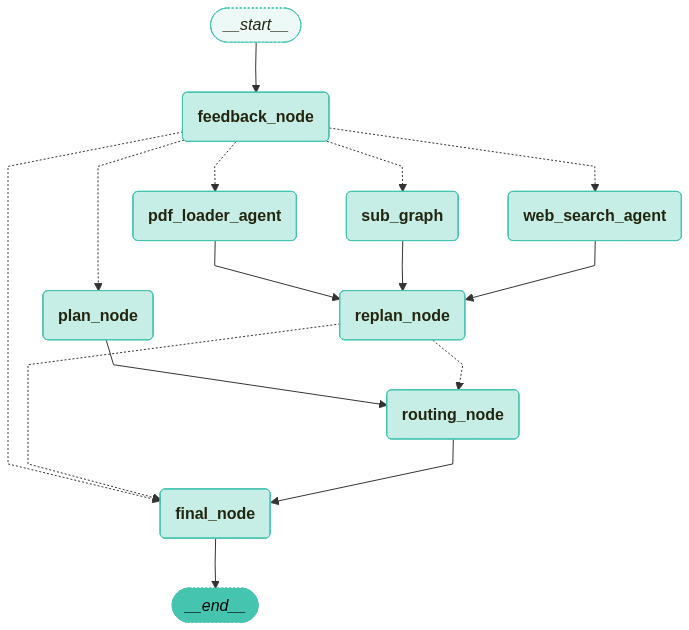

In [20]:
visualize_graph(graph)

In [17]:
inputs = {"question": "안녕 난 Kara Nielsen 이야"}
config = get_runnable_config(recursion_limit=20, thread_id=get_random_uuid())
# stream_graph(graph, inputs, config)

for event in graph.stream(inputs, config=config, stream_mode="values"):
    print(event)
    print("=========" * 10 + "\n\n")

{'question': '안녕 난 Kara Nielsen 이야', 'messages': [], 'past_steps': []}


{'question': '안녕 난 Kara Nielsen 이야', 'messages': [], 'past_steps': [], 'human_feedback': False}


{'question': '안녕 난 Kara Nielsen 이야', 'plan': ['Kara Nielsen님, 안녕하세요!', '무엇을 도와드릴까요?'], 'messages': [], 'past_steps': [], 'human_feedback': False}




AttributeError: 'NoneType' object has no attribute 'datasource'

In [ ]:
# inputs = {"question": "내 FavoriteMusic 보여줘"}
# for event in graph.stream(inputs, config=config, stream_mode="values"):
#     print(event)
# print("=========" * 10 + "\n\n")

In [ ]:
# inputs = {"question": "그중에서 비오는날 듣기좋은노래로 추천해줘"}
# for event in graph.stream(inputs, config=config, stream_mode="values"):
#     print(event)
#     print("=========" * 10 + "\n\n")

In [ ]:
# to_replay = None

# # 상태 기록 가져오기
# for i, state in enumerate(graph.get_state_history(config)):
#     # 메시지 수 및 다음 상태 출력
#     print(i)
#     print(state.values)
#     print("\n\n")
#     if i == 2:
#         to_replay = state

In [ ]:
# plan = ['오늘 서울 날씨 확인 후 오늘 날씨에 어울리는 재즈 음악 5곡 웹에서 검색하여 추천', '추천한 재즈 음악이 서비스에 있는지 확인', '최종 추천 목록 생성']
# updated_state = graph.update_state(
#     # 업데이트할 상태 지정
#     to_replay.config,
#     # 제공할 업데이트된 값. `State`의 메시지는 "추가 전용"으로 기존 상태에 추가됨
#     {"plan": plan},
# )
# for event in graph.stream(None, updated_state, stream_mode="values"):
#     print(event)

In [ ]:
# snapshot = graph.get_state(config)
# print(snapshot)

In [ ]:
# inputs = {"question": "ㅇㅇ 그렇게해"}
# for event in graph.stream(inputs,config=config,stream_mode='values'):
#     print(event)
#     print("========="*10+"\n\n")

In [ ]:
# inputs = {"question": "팝송 5곡 추천해줘"}
# stream_graph(graph, inputs, config)